<a href="https://colab.research.google.com/github/Aleska134/AI-Projects/blob/main/06-Intro-to-ML/Non-Guided-Project/GroupLab_Week_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Group Lab: Explore & Predict

**CAI1001C: AI Thinking | Miami Dade College**
**Week 6 — Machine Learning**

---

### Instructions

- Work in your assigned group (3–4 people)
- **You will NOT write any code from scratch**
- At each `▶ MODIFY` point, change the value indicated, re-run the cell, and observe what happens
- Answer every **🔍 Checkpoint** question in the space provided — these are your deliverables
- One submission per group — make sure everyone's name is below

---

**Group Members:**

1. Aleska B
2. Andrea M
3. Michael B
4. Melissa_D
5. German R


In [1]:
# ============================================
# SETUP — Run this cell first, do NOT modify
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the Miami restaurant dataset
df = pd.read_csv("miami_restaurants.csv")

# Pre-build the model (same as the demo)
X = df[["seating_capacity", "avg_meal_price", "yelp_rating", "years_open"]]
y = df["monthly_revenue"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Setup complete. Dataset loaded, model trained.")
print(f"   {len(df)} restaurants | 4 features | R² = {model.score(X_test, y_test):.2f}")


✅ Setup complete. Dataset loaded, model trained.
   60 restaurants | 4 features | R² = 0.77


---

## Part A: Data Visualization (C3.1)

In the demo, we made a scatter plot of Yelp rating vs. revenue. Now it's your turn to explore other relationships in the data.

---

### A1. Explore a Different Relationship


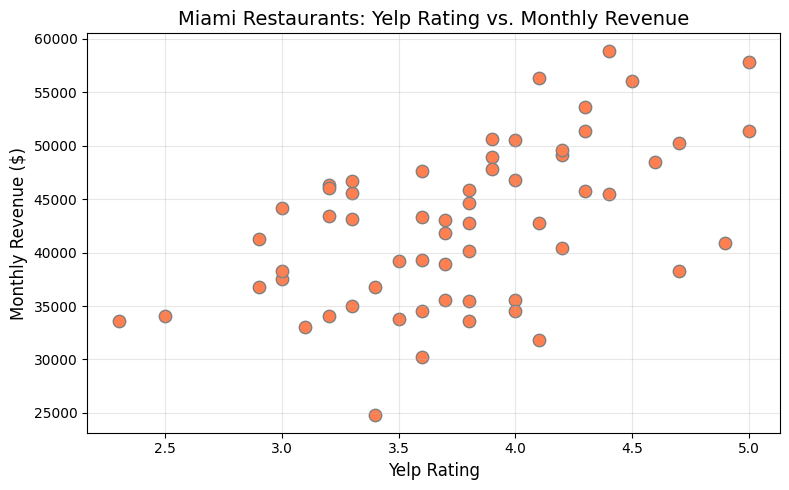

In [2]:
# ============================================
# A1: Scatter Plot — Explore a relationship
# ============================================
# The demo showed yelp_rating vs monthly_revenue.
# Now YOU pick a different feature to explore.

# ▶ MODIFY THIS: Change the feature on the x-axis
# Options: "seating_capacity", "avg_meal_price", "yelp_rating", "years_open"
x_feature = "yelp_rating"

# --- Do not modify below this line ---
plt.figure(figsize=(8, 5))
plt.scatter(df[x_feature], df["monthly_revenue"], color="coral", edgecolors="gray", s=80)
plt.xlabel(x_feature.replace("_", " ").title(), fontsize=12)
plt.ylabel("Monthly Revenue ($)", fontsize=12)
plt.title(f"Miami Restaurants: {x_feature.replace('_', ' ').title()} vs. Monthly Revenue", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 🔍 Checkpoint A1

**Which feature did your group choose?** yelp_rating

**Do you see a pattern?** (circle one):  Clear upward trend  /  Slight trend  /  No obvious pattern

**In 2–3 sentences, describe what the chart tells you:**

_Your answer: The chart shows a clear upward trend. Restaurants with higher Yelp ratings generally tend to generate higher monthly revenues. This suggests that customer satisfaction, as reflected in Yelp reviews, is a significant factor influencing a restaurant's financial success.






---

### A2. Bar Chart — Compare Categories

Let's group restaurants by Yelp rating and see average revenue for each group.


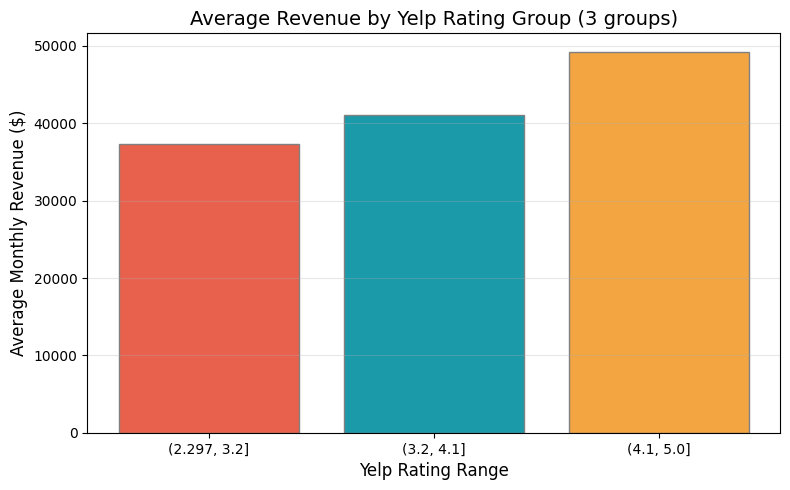

Revenue difference between lowest and highest group: $11,809


In [3]:
# ============================================
# A2: Bar Chart — Average revenue by rating group
# ============================================
# This groups restaurants into rating buckets and shows average revenue

# ▶ MODIFY THIS: Change the number of groups (try 3, 4, or 5)
num_groups = 3

# --- Do not modify below this line ---
df["rating_group"] = pd.cut(df["yelp_rating"], bins=num_groups, labels=False) + 1
group_labels = pd.cut(df["yelp_rating"], bins=num_groups)
avg_by_group = df.groupby(group_labels, observed=True)["monthly_revenue"].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(avg_by_group)), avg_by_group.values, color=["#E8614D", "#1B9AAA", "#F2A541", "#1E3A5F", "#84B59F"][:num_groups], edgecolor="gray")
plt.xticks(range(len(avg_by_group)), [str(x) for x in avg_by_group.index], fontsize=10)
plt.xlabel("Yelp Rating Range", fontsize=12)
plt.ylabel("Average Monthly Revenue ($)", fontsize=12)
plt.title(f"Average Revenue by Yelp Rating Group ({num_groups} groups)", fontsize=14)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Revenue difference between lowest and highest group: ${avg_by_group.max() - avg_by_group.min():,.0f}")
df.drop(columns=["rating_group"], inplace=True)


### 🔍 Checkpoint A2

**How many groups did you use?** 3

**What's the revenue difference between the lowest and highest group?** $ 11,809

**When you changed the number of groups, did the story change? How?**

_Your answer: Yes, there is a change. The chart looks simpler for one and there was a change in the revenue difference by about 2,000$


---

### 🔍 Checkpoint A3 — Honest Charts (C2.1)

Look at the bar chart you just made.

**If a restaurant owner only showed you the chart with 2 groups (low vs. high), it would look like there's a dramatic difference. With 5 groups, the picture is more nuanced. Think about this:**

**Could someone use data visualization to mislead people — even without lying? How?**

_Your answer: Yes, you can hide quite a lot about what is actually going on by showing even less on the chart. There are significant revenue differences the more data is shown.






---

## Part B: Machine Learning — Change and Observe (C1.4, C3.3)

The model is already trained from the setup cell. Now you're going to interact with it — change inputs, observe outputs, and interpret what happens.

---

### B1. Make Your Own Prediction

In the demo, we predicted revenue for Sofia's restaurant. Now design your own.


In [4]:
# ============================================
# B1: Predict revenue for YOUR restaurant
# ============================================

# ▶ MODIFY ALL FOUR VALUES below
# Design a restaurant your group would open in Miami

my_seats = 50             # How many seats? (range in data: 20-119)
my_meal_price = 21.00     # Average meal price? (range: $8-$45)
my_yelp_rating = 4.0      # Yelp rating? (range: 2.0-5.0)
my_years_open = 5         # Years in business? (range: 1-24)

# --- Do not modify below this line ---
my_restaurant = pd.DataFrame({
    "seating_capacity": [my_seats],
    "avg_meal_price": [my_meal_price],
    "yelp_rating": [my_yelp_rating],
    "years_open": [my_years_open]
})

predicted = model.predict(my_restaurant)[0]

print("🍽️  Your Restaurant")
print("=" * 40)
print(f"  Seats:          {my_seats}")
print(f"  Avg meal price: ${my_meal_price:.2f}")
print(f"  Yelp rating:    {my_yelp_rating} ⭐")
print(f"  Years open:     {my_years_open}")
print(f"")
print(f"  💰 Predicted monthly revenue: ${predicted:,.0f}")


🍽️  Your Restaurant
  Seats:          50
  Avg meal price: $21.00
  Yelp rating:    4.0 ⭐
  Years open:     5

  💰 Predicted monthly revenue: $36,405


### 🔍 Checkpoint B1

**Describe the restaurant your group designed** (name it if you want!):

_Your answer:Our group designed a restaurant with 50 seats, an average meal price of $21.00, a Yelp rating of 4.0 stars, and 5 years in business. We imagine it as a cozy, mid-range establishment offering quality food and good service.



**What was the predicted revenue?** $ 36,405

**Does the prediction seem reasonable? Why or why not?**

_Your answer: Yes, the prediction of $36,405 seems reasonable. Given the moderate seating capacity, average meal price, and good Yelp rating, this revenue aligns with what a well-performing, established restaurant of this type might expect in Miami. It's not extremely high or low, suggesting the model's prediction is plausible within the context of the dataset.





---

### B2. What Matters Most?

Now test which feature has the biggest impact. Change ONE value at a time and record what happens.


In [5]:
# ============================================
# B2: Test feature impact — change ONE thing at a time
# ============================================
# Start from this BASELINE restaurant:

baseline = {"seating_capacity": 60, "avg_meal_price": 20, "yelp_rating": 3.5, "years_open": 5}

# ▶ MODIFY: Change ONE value in each test below.
# Keep all other values the same as the baseline.

test_1 = {"seating_capacity": 100, "avg_meal_price": 20, "yelp_rating": 3.5, "years_open": 5}  # Changed: seats
test_2 = {"seating_capacity": 60, "avg_meal_price": 40, "yelp_rating": 3.5, "years_open": 5}   # Changed: price
test_3 = {"seating_capacity": 60, "avg_meal_price": 20, "yelp_rating": 4.8, "years_open": 5}   # Changed: rating
test_4 = {"seating_capacity": 60, "avg_meal_price": 20, "yelp_rating": 3.5, "years_open": 20}  # Changed: years
test_5 = {"seating_capacity": 60, "avg_meal_price": 20, "yelp_rating": 3.5, "years_open": 5} # 5 years

# --- Do not modify below this line ---
tests = {"Baseline": baseline, "More Seats (100)": test_1, "Higher Price ($40)": test_2,
         "Higher Rating (4.8)": test_3, "More Years (20)": test_4, "Less years (5)": test_5}

print(f"{'Scenario':<25} {'Revenue':>12}  {'Difference':>12}")
print("=" * 52)
base_pred = model.predict(pd.DataFrame([baseline]))[0]

for name, values in tests.items():
    pred = model.predict(pd.DataFrame([values]))[0]
    diff = pred - base_pred
    marker = "" if name == "Baseline" else f"  {'⬆️' if diff > 0 else '⬇️'}"
    diff_str = "—" if name == "Baseline" else f"${diff:+,.0f}"
    print(f"{name:<25} ${pred:>10,.0f}  {diff_str:>12}{marker}")


Scenario                       Revenue    Difference
Baseline                  $    35,891             —
More Seats (100)          $    43,178       $+7,287  ⬆️
Higher Price ($40)        $    41,097       $+5,206  ⬆️
Higher Rating (4.8)       $    41,286       $+5,395  ⬆️
More Years (20)           $    40,755       $+4,864  ⬆️
Less years (5)            $    35,891           $+0  ⬇️


### 🔍 Checkpoint B2

**Fill in the table from your output:**

| Change Made | Predicted Revenue | Difference from Baseline |
|---|---|---|
| Baseline (60 seats, $20, 3.5⭐, 5 yrs) | $35,891 | — |
| More Seats (100) | $43,178 | $7,287 |
| Higher Price ($40) | $ | $ |
| Higher Rating (4.8) | $ | $ |
| More Years (20) | $ | $ |

**Which single change had the biggest impact on revenue?** More seats (100)

**Does this surprise you? What does it tell a restaurant owner about where to focus their effort?**

_Your answer:This might be surprising to some, as one might expect a higher Yelp rating or meal price to have the most significant impact. The model suggests that increasing seating capacity has the biggest positive effect on revenue. This tells a restaurant owner that expanding their physical capacity to serve more customers could be a highly effective strategy for boosting monthly revenue, perhaps more so than slight increases in pricing or even improving Yelp ratings by a small margin. It emphasizes volume over slight changes in other factors.






---

### 🔍 Checkpoint B3 — Whose Data, Whose Predictions? (C2.1, C2.2)

The model you just used was trained on 48 Miami restaurants. Think critically about that.

**1. If this dataset was mostly high-end Brickell restaurants, would the predictions be accurate for a family-run spot in Hialeah or Homestead? Why or why not?**

_Your answer: No, the predictions would likely not be accurate. Machine learning models are heavily influenced by the data they are trained on. If the model was trained primarily on high-end Brickell restaurants, it would learn patterns and relationships specific to that demographic, pricing, customer base, and operational costs. These factors would be significantly different for a family-run spot in Hialeah or Homestead, which likely caters to a different clientele with different spending habits and expectations. The model would fail to generalize to a different market segment.



**2. Imagine a bank uses a model like this — trained on past loan data — to decide who gets a business loan. If the training data mostly contains large chain restaurants, what happens to small family-owned businesses applying for loans?**

_Your answer: If a bank's loan model is trained predominantly on large chain restaurants, small family-owned businesses would likely face significant challenges in securing loans. The model would have learned the financial profiles, risk assessments, and performance metrics of large, well-established chains. Small businesses, which often have different financial structures, less collateral, or shorter operating histories, would not fit these established patterns and could be unfairly flagged as high-risk or simply not meet the model's criteria, leading to denied loans.



**3. Who is responsible when a model makes an unfair prediction — the developer who built it, the company that uses it, or the people who collected the training data?**

_Your answer:Responsibility for unfair predictions is shared across all parties: the developer, the company using it, and those who collected the data. The data collectors are responsible for ensuring data quality and representativeness. Developers are responsible for understanding data limitations, building robust and fair algorithms, and testing for bias. The company using the model has the ultimate responsibility to ensure its ethical application, understand its limitations, monitor its impact, and implement safeguards against discriminatory outcomes. It's a collective ethical and technical responsibility.





---

## Part C: Putting It Together (C1.4)

### B4. What Kind of Learning Is This?


In [6]:
# ============================================
# B4: Review — what the model actually does
# ============================================
# Run this cell to see a summary of the model

print("Model Type: Linear Regression")
print("Learning Type: Supervised Learning")
print()
print("Why supervised?")
print("  → We gave the model LABELED data (we told it the correct revenue for each restaurant)")
print("  → The model learned the relationship between features and the label")
print("  → Now it can predict the label for NEW, unseen restaurants")
print()
print("This is REGRESSION (predicting a number), not CLASSIFICATION (predicting a category).")
print()
print("Features (inputs):")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat:20s}  →  coefficient: ${coef:,.0f} per unit")
print()
print(f"R² Score: {model.score(X_test, y_test):.2f}")
print(f"  → The model explains {model.score(X_test, y_test)*100:.0f}% of the variation in revenue")
print(f"  → The other {(1-model.score(X_test, y_test))*100:.0f}%? Things we didn't measure (location, marketing, chef skill...)")


Model Type: Linear Regression
Learning Type: Supervised Learning

Why supervised?
  → We gave the model LABELED data (we told it the correct revenue for each restaurant)
  → The model learned the relationship between features and the label
  → Now it can predict the label for NEW, unseen restaurants

This is REGRESSION (predicting a number), not CLASSIFICATION (predicting a category).

Features (inputs):
  seating_capacity      →  coefficient: $182 per unit
  avg_meal_price        →  coefficient: $260 per unit
  yelp_rating           →  coefficient: $4,150 per unit
  years_open            →  coefficient: $324 per unit

R² Score: 0.77
  → The model explains 77% of the variation in revenue
  → The other 23%? Things we didn't measure (location, marketing, chef skill...)


### 🔍 Checkpoint C1 — Identify the Concepts

**Match each term to what it means in THIS lab (not the textbook definition — use your own words based on what you just did):**

**Features:** _Your definition: These are the input characteristics of a restaurant that the model uses to make a prediction, such as 'seating_capacity', 'avg_meal_price', 'yelp_rating', and 'years_open'.


**Label:** _Your definition: This is the target value the model is trying to predict, which in this lab is the 'monthly_revenue' of a restaurant.


**Training set:** _Your definition: This is a smaller, separate portion of the Miami restaurant dataset that the model had not seen before, used to evaluate how well it can predict revenue on new, unseen data.


**Test set:** _Your definition: This is a smaller, separate portion of the Miami restaurant dataset that the model had not seen before, used to evaluate how well it can predict revenue on new, unseen data.


**R² score:** _Your definition: This score, typically between 0 and 1, tells us what percentage of the variation in monthly revenue can be explained by our model's features. A higher score means the model is better at explaining the outcomes.


**Supervised learning:** _Your definition: This is the type of machine learning where we provide the model with a dataset containing both the input features and the correct output labels (monthly revenue), so it can learn from examples.


**Regression:** _Your definition: This refers to the task of predicting a continuous numerical value, which in this lab is predicting the 'monthly_revenue' in dollars, as opposed to classifying into categories.




---

### 🔍 Checkpoint C2 — Final Reflection (C2.1, C2.2)

**As a group, discuss and answer ONE of the following:**

**Option A:** You built a model that predicts restaurant revenue. A city government wants to use a similar model to decide which neighborhoods get new restaurant permits. What could go wrong? Who benefits, who gets left out?

**Option B:** The model says Yelp rating is the single most important factor for revenue. But Yelp reviews can be faked, biased, or manipulated. If a business decision depends on this model, what are the risks of trusting it?

**Option C:** Machine learning models learn patterns from PAST data. If the past was unfair (certain groups had less access to funding, worse locations, fewer reviews), the model will learn that unfairness as if it were a fact. How should we handle this?

**Your group chose Option: B **

_Your answer (4–6 sentences minimum): The model states that Yelp rating is the single most important factor for revenue, but trusting this blindly carries significant risks. If Yelp reviews can be faked or manipulated, decisions based on this model could lead to misallocated resources, favoring businesses that have artificially inflated their ratings over those with genuine quality. This could also incentivize businesses to focus on review manipulation rather than actual customer service or product improvement. Ultimately, relying on a potentially biased input factor compromises the integrity and reliability of the model's predictions, leading to poor strategic outcomes and an unfair market environment. The 'truth' the model learns might not reflect reality, but rather a manipulated version of it.






---

## ✅ Submission

**Before submitting, make sure:**
- [ ] All `▶ MODIFY` cells have been changed and re-run
- [ ] All 🔍 Checkpoint answers are filled in
- [ ] All group members' names are at the top

**Save this notebook** (File → Download .ipynb) and submit one copy per group.

---

*CAI1001C: AI Thinking | Miami Dade College | Prof. Carlos Marquez*
